# Reconstrução do TCC — recomendação de campanhas de crédito

## 1. Descrição do projeto

**Origem:** tese, capítulos 3–5; notebook forense recuperado.  
**Tipo:** narrativa nova de reconstrução.  
**Objetivo:** reconstruir duas provas de conceito para segmentar perfis e recomendar campanhas de crédito: uma abordagem baseada em conteúdo e uma abordagem preditiva com score e taxa personalizada.

A tese é a fonte primária da metodologia pretendida. O notebook recuperado fornece evidência forense de implementação, inclusive quando contradiz a narrativa publicada. Resultados reconstruídos são apresentados como reproduzidos, parciais, divergentes, conflitantes ou irreproduzíveis; proximidade numérica não é tratada como prova de equivalência.

## 2. Notas de reprodutibilidade

**Origem:** decisões metodológicas das Fases 1–6.  
**Tipo:** novo.  
**Mudança:** sementes, versões, populações e fronteiras são explícitas; nenhum estado oculto do notebook recuperado é presumido.

A execução validada usa Python 3.12 e dependências fixadas em `requirements.txt`. As sementes são 42 para amostras analíticas/PoC 1 e 1 para divisão, balanceamento e modelos da PoC 2. Transformadores e balanceamento aprendem somente com treino; o teste permanece na distribuição natural. Tabelas exibem agregados, não registros individuais, e nenhum dataset ou modelo binário é versionado.

## 3. Aquisição do dataset

**Origem:** tese, seção 4.2; notebook recuperado, caminho da célula 6; manifesto reconstruído.  
**Tipo:** adaptado.  
**Mudança:** o caminho absoluto do Colab foi substituído por configuração explícita, variável `LENDING_CLUB_DATA_PATH` ou descoberta controlada em `data/raw/`.

O artefato validado é `Loan_status_2007-2020Q3.gzip`, obtido do dataset Kaggle cujo slug termina em Q1, mas cujo conteúdo alcança setembro de 2020. Possui 2.925.493 linhas e 142 colunas, como a tese. O arquivo real permanece fora do Git; hash, tamanho, período e instruções estão em `provenance/dataset-manifest.json` e `docs/dataset-acquisition.md`.

## 4. Imports e configuração

**Origem:** tese, seção 4.2; notebook recuperado, células 6–9 e 26; pipeline novo da Fase 2.  
**Tipo:** adaptado.  
**Mudança:** imports mantidos em uma célula, caminho configurável e configuração visual determinística.  
**Resultado esperado:** ambiente preparado sem download implícito, credenciais ou caminho local absoluto.

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns

from tcc_reconstruction.data import (
    DATA_PATH_ENV,
    DataPipelineConfig,
    VERIFIED_INCOME_STATUSES,
    inspect_schema,
    run_data_pipeline,
)
from tcc_reconstruction.eda import (
    FIGURE_TITLES,
    add_log1p_columns,
    aggregate_column_profile,
    calculate_pearson_correlations,
    deterministic_plot_sample,
    select_defaulted_loans,
)

SEED = 42
PLOT_SAMPLE_SIZE = 100_000
DEFAULT_DATASET = Path("data/raw/Loan_status_2007-2020Q3.gzip")
DATASET_PATH = Path(os.environ.get(DATA_PATH_ENV, DEFAULT_DATASET))

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 10)

## 5. Carregamento e populações analíticas

**Origem:** tese, seção 4.2; notebook recuperado, células 6–9 e 26; pipeline novo da Fase 2.  
**Tipo:** adaptado.  
**Mudança:** validação de esquema antes da leitura, seleção de colunas, leitura em blocos, conversões estritas e filtros auditáveis.  
**População EDA inicial:** `Fully Paid`, `Charged Off` e `Default`, sem filtro de verificação.  
**População de modelagem:** a população anterior restrita a `Verified` e `Source Verified`.

In [2]:
pipeline_result = run_data_pipeline(
    DataPipelineConfig(
        dataset_path=DATASET_PATH,
        sample_size=None,
        random_seed=SEED,
        verified_only=False,
    )
)
all_loans = pipeline_result.data
verified_loans = all_loans[
    all_loans["verification_status"].isin(VERIFIED_INCOME_STATUSES)
]

population_summary = pd.DataFrame(
    {
        "população": [
            "arquivo bruto",
            "status finais (Figuras 9–15)",
            "status finais + renda verificada (Figuras 16–19)",
        ],
        "registros": [
            pipeline_result.summary.rows_read,
            len(all_loans),
            len(verified_loans),
        ],
    }
)
population_summary

,população,registros
0,arquivo bruto,2925493
1,status finais (Figuras 9–15),1860764
2,status finais + renda verificada (Figuras 16–19),1272273


In [3]:
plot_sample_all = deterministic_plot_sample(
    all_loans, sample_size=PLOT_SAMPLE_SIZE, seed=SEED
)
plot_sample_verified = deterministic_plot_sample(
    verified_loans, sample_size=PLOT_SAMPLE_SIZE, seed=SEED
)
plot_sample_verified = add_log1p_columns(plot_sample_verified)

sampling_summary = pd.DataFrame(
    {
        "uso": ["Figuras 9–15", "Figuras 16–19"],
        "população_para_métricas": [len(all_loans), len(verified_loans)],
        "amostra_somente_para_renderização": [
            len(plot_sample_all),
            len(plot_sample_verified),
        ],
        "semente": [SEED, SEED],
    }
)
sampling_summary

,uso,população_para_métricas,amostra_somente_para_renderização,semente
0,Figuras 9–15,1860764,100000,42
1,Figuras 16–19,1272273,100000,42


## 6. Análise exploratória dos dados

**Origem:** tese, Figuras 9–19; notebook recuperado, células 8–20 e 49–51.  
**Tipo:** adaptado e complementado.  
**Mudança:** filtros de população explícitos, APIs atuais, estatísticas calculadas na população completa e amostra determinística somente para renderização.

### Figura 9 — Distribuição do Montante de Empréstimo por Ano

**Origem:** tese, Figura 9; notebook recuperado, células 19–20.  
**Tipo:** adaptado.  
**População:** empréstimos nos três status finais, exceto 2020, que é um ano incompleto no arquivo Q3. O boxplot usa a amostra determinística apenas para limitar o custo de renderização; as contagens e correlações desta análise usam as populações completas.

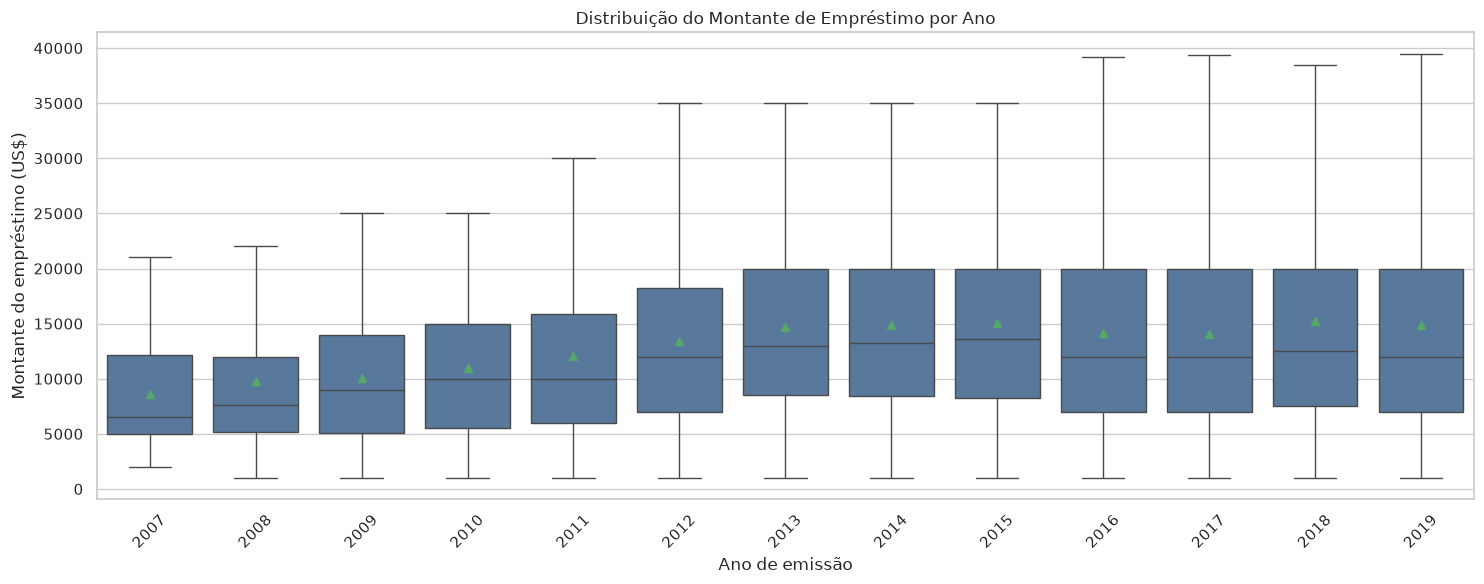

In [4]:
figure_9_data = plot_sample_all[plot_sample_all["year"] != 2020]
plt.figure(figsize=(15, 6))
ax = sns.boxplot(
    data=figure_9_data,
    x="year",
    y="loan_amnt",
    color="#4c78a8",
    showmeans=True,
    showfliers=False,
)
ax.set(
    title=FIGURE_TITLES[9],
    xlabel="Ano de emissão",
    ylabel="Montante do empréstimo (US$)",
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Figuras 10–12 — Correlações de Pearson

**Origem:** tese, Figuras 10–12; ausentes no notebook recuperado.  
**Tipo:** novo.  
**População:** empréstimos nos três status finais; cada coeficiente usa todos os pares não ausentes. A amostra determinística é usada somente para desenhar os pontos. Os valores são recalculados abaixo e não são fixados em texto.

In [5]:
correlations = calculate_pearson_correlations(all_loans)
correlations

,variavel_x,variavel_y,n_pares_validos,correlacao_pearson
0,loan_amnt,funded_amnt,1860764,0.999700
1,fico_range_low,fico_range_high,1860764,1.000000
2,total_acc,open_acc,1860764,0.708775


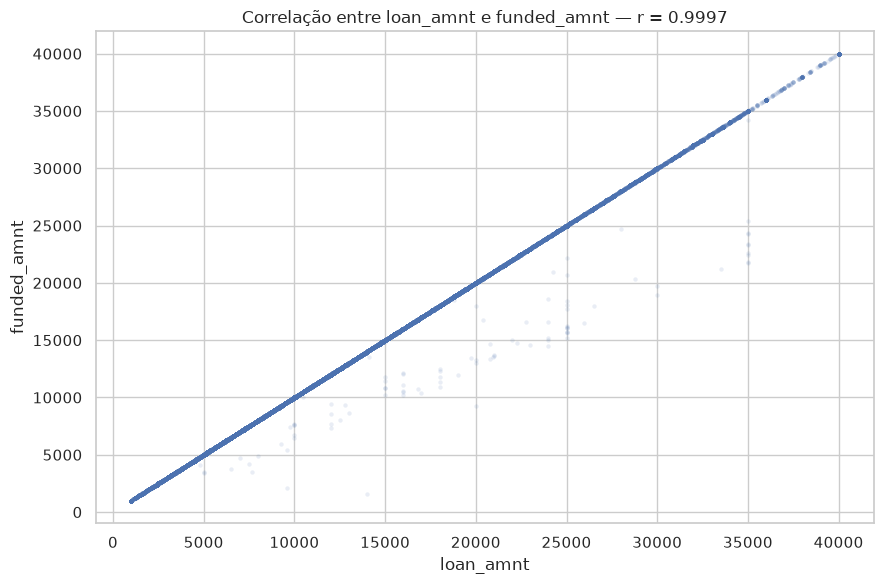

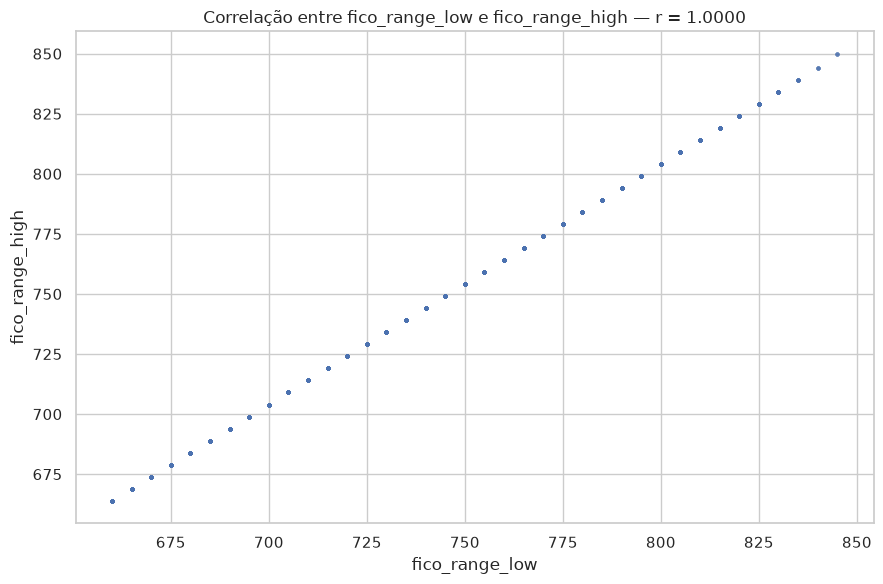

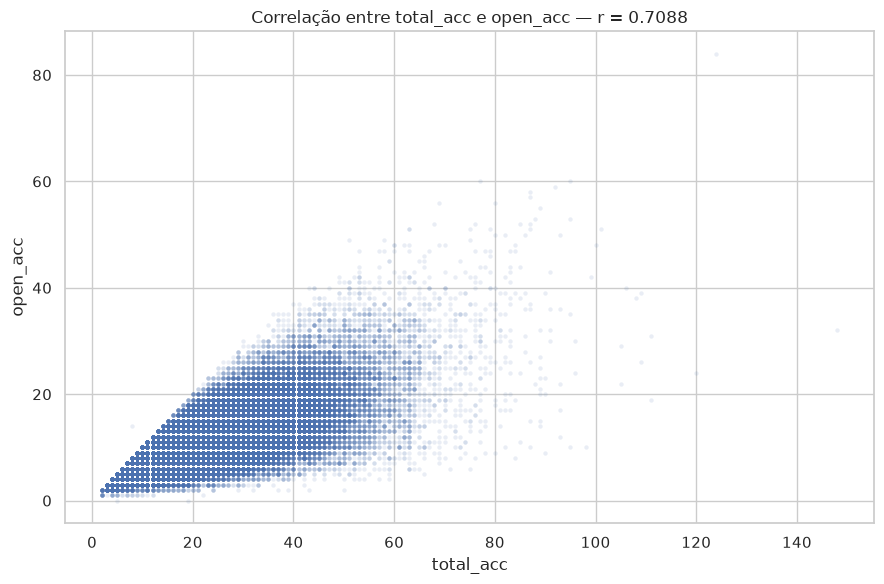

In [6]:
correlation_figures = [
    (10, "loan_amnt", "funded_amnt"),
    (11, "fico_range_low", "fico_range_high"),
    (12, "total_acc", "open_acc"),
]

for figure_number, x_column, y_column in correlation_figures:
    correlation = correlations.loc[
        (correlations["variavel_x"] == x_column)
        & (correlations["variavel_y"] == y_column),
        "correlacao_pearson",
    ].iloc[0]
    chart_data = plot_sample_all[[x_column, y_column]].dropna()
    plt.figure(figsize=(9, 6))
    ax = sns.scatterplot(
        data=chart_data,
        x=x_column,
        y=y_column,
        alpha=0.12,
        s=10,
        linewidth=0,
    )
    ax.set_title(f"{FIGURE_TITLES[figure_number]} — r = {correlation:.4f}")
    plt.tight_layout()
    plt.show()

### Figura 13 — Gráfico de Barras das Razões de Inadimplência

**Origem:** tese, Figura 13; notebook recuperado, células 11–12.  
**Tipo:** adaptado com correção metodológica.  
**Mudança:** o código recuperado contava também empréstimos pagos.  
**População:** somente `Charged Off` e `Default`, sem filtro de verificação de renda.

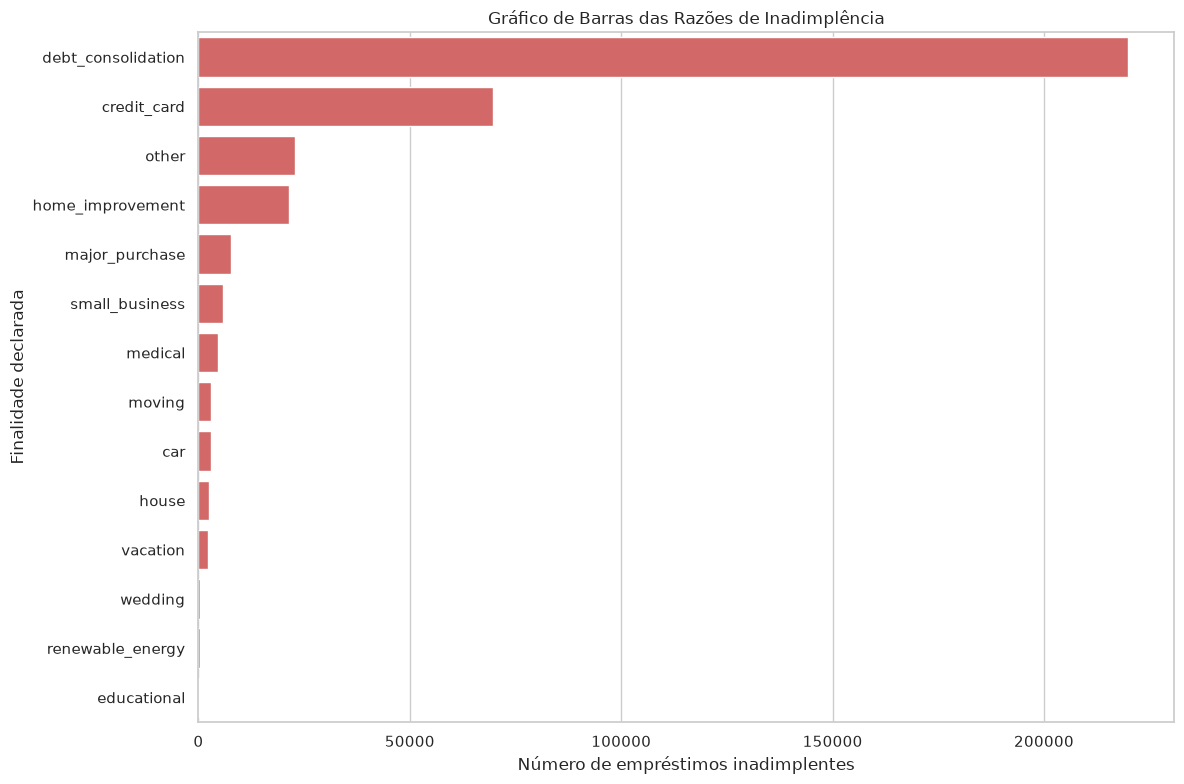

,inadimplentes
finalidade,
debt_consolidation,219761
credit_card,69656
other,22775
home_improvement,21357
major_purchase,7720
small_business,5868
medical,4613
moving,2917
car,2858


In [7]:
defaulted_loans = select_defaulted_loans(all_loans)
purpose_counts = (
    defaulted_loans["purpose"]
    .astype("string")
    .fillna("<ausente>")
    .value_counts()
    .rename_axis("finalidade")
    .rename("inadimplentes")
)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x=purpose_counts.values,
    y=purpose_counts.index,
    color="#e45756",
)
ax.set(
    title=FIGURE_TITLES[13],
    xlabel="Número de empréstimos inadimplentes",
    ylabel="Finalidade declarada",
)
plt.tight_layout()
plt.show()
purpose_counts.to_frame()

### Figura 14 — Mapa Coroplético de Empréstimos por Estado

**Origem:** tese, Figura 14; notebook recuperado, células 13–15.  
**Tipo:** adaptado para Plotly atual.  
**População:** empréstimos nos três status finais, sem filtro de verificação de renda.

In [8]:
state_counts = (
    all_loans["addr_state"]
    .astype("string")
    .dropna()
    .value_counts()
    .rename_axis("estado")
    .rename("empréstimos")
    .reset_index()
)

figure_14 = go.Figure(
    data=go.Choropleth(
        locations=state_counts["estado"],
        z=state_counts["empréstimos"],
        locationmode="USA-states",
        colorscale="Cividis",
        colorbar_title="Empréstimos",
    )
)
figure_14.update_layout(
    title=FIGURE_TITLES[14],
    geo_scope="usa",
    height=550,
)
figure_14.show()

### Figura 15 — Distribuição da Relação Dívida/Renda (DTI)

**Origem:** tese, Figura 15; notebook recuperado, células 16–18.  
**Tipo:** adaptado; `histplot` substitui APIs obsoletas.  
**População:** empréstimos nos três status finais com DTI não ausente. O resumo usa toda a população. Para tornar a concentração central legível, o histograma exclui o sentinela negativo e limita visualmente o eixo ao percentil 99; os valores excluídos continuam contabilizados no resumo.

In [9]:
dti_non_null = all_loans["dti"].dropna()
dti_summary = all_loans["dti"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame("dti")
dti_anomalies = pd.DataFrame(
    {
        "regra": ["ausente", "negativo (sentinela/anomalia)", "acima do percentil 99"],
        "registros": [
            int(all_loans["dti"].isna().sum()),
            int((dti_non_null < 0).sum()),
            int((dti_non_null > dti_non_null.quantile(0.99)).sum()),
        ],
    }
)
display(dti_summary)
display(dti_anomalies)

,dti
count,1.859655e+06
mean,1.856806e+01
std,1.309105e+01
min,-1.000000e+00
50%,1.771000e+01
90%,3.015000e+01
95%,3.345000e+01
99%,3.961000e+01
max,9.990000e+02


,regra,registros
0,ausente,1109
1,negativo (sentinela/anomalia),2
2,acima do percentil 99,18561


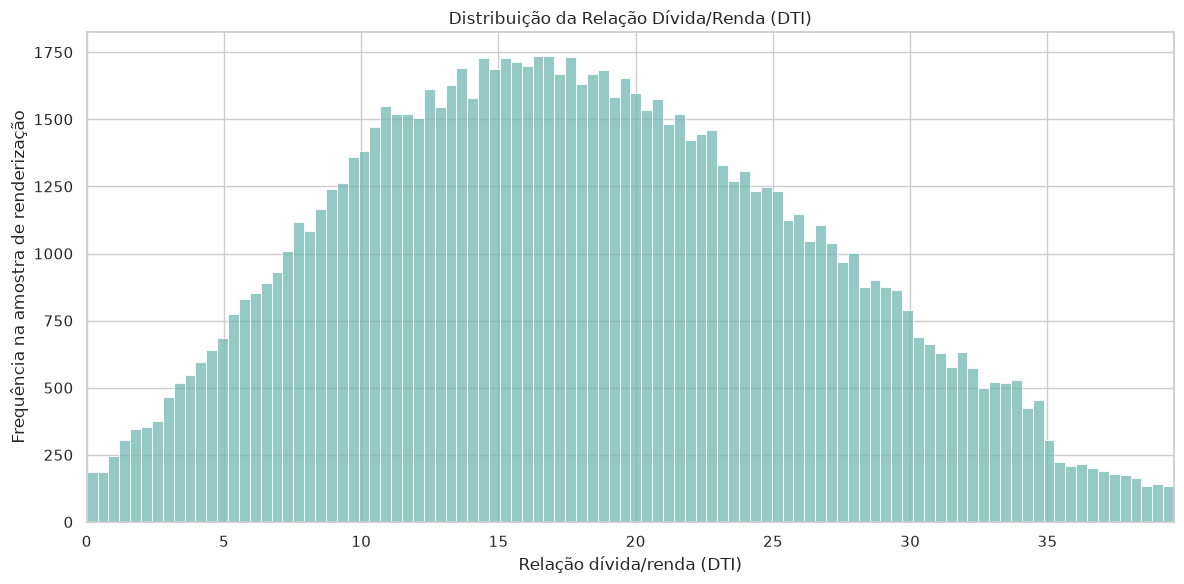

In [10]:
figure_15_limit = dti_non_null[dti_non_null >= 0].quantile(0.99)
figure_15_data = plot_sample_all[
    plot_sample_all["dti"].between(0, figure_15_limit, inclusive="both")
]
plt.figure(figsize=(12, 6))
ax = sns.histplot(
    data=figure_15_data,
    x="dti",
    bins=100,
    color="#72b7b2",
)
ax.set_xlim(0, figure_15_limit)
ax.set(
    title=FIGURE_TITLES[15],
    xlabel="Relação dívida/renda (DTI)",
    ylabel="Frequência na amostra de renderização",
)
plt.tight_layout()
plt.show()

### Figuras 16–17 — Renda anual antes e depois de `log1p`

**Origem:** tese, Figuras 16–17; notebook recuperado, células 49 e 51.  
**Tipo:** adaptado; `histplot` com densidade substitui `distplot`.  
**População:** empréstimos nos três status finais com renda `Verified` ou `Source Verified`; valores ausentes são ignorados. A transformação é uma cópia analítica e não altera o pipeline da Fase 2. Para evitar que poucos extremos ocultem o formato, cada eixo mostra os percentis 0,5–99,5 da respectiva variável; os perfis tabulares preservam os extremos completos.

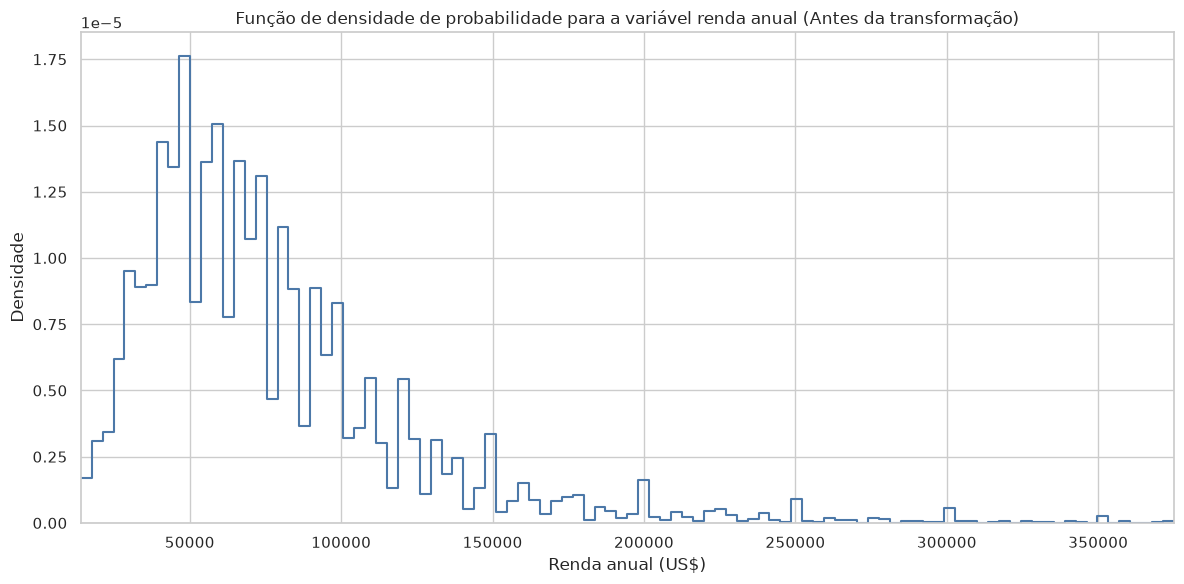

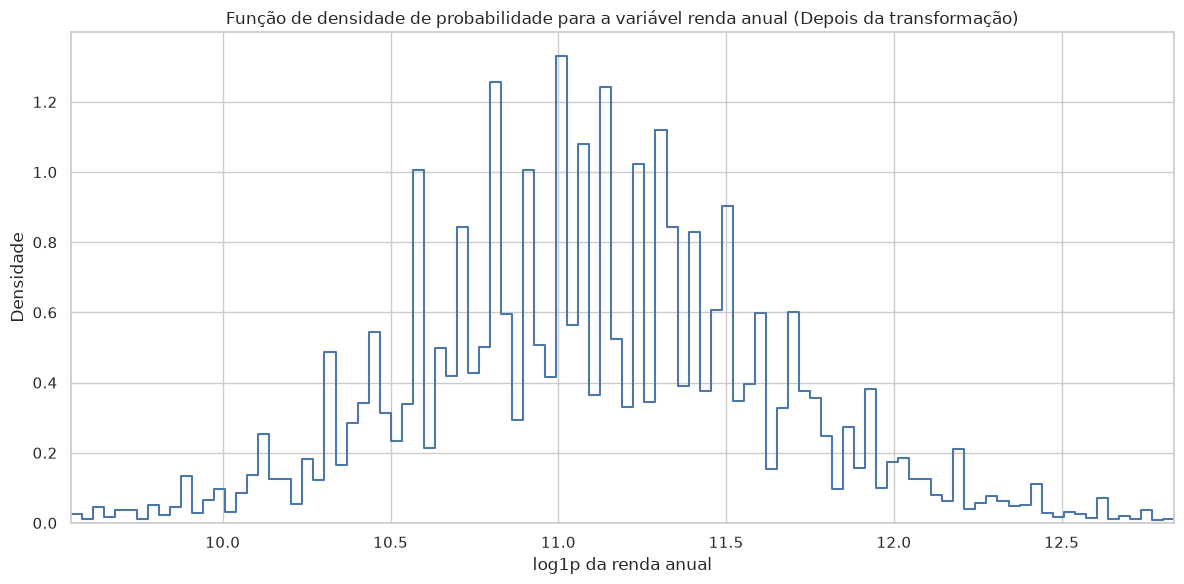

In [11]:
for figure_number, column, xlabel in (
    (16, "annual_inc", "Renda anual (US$)"),
    (17, "annual_inc_log1p", "log1p da renda anual"),
):
    lower, upper = plot_sample_verified[column].quantile([0.005, 0.995])
    chart_data = plot_sample_verified[
        plot_sample_verified[column].between(lower, upper, inclusive="both")
    ]
    plt.figure(figsize=(12, 6))
    ax = sns.histplot(
        data=chart_data,
        x=column,
        bins=100,
        stat="density",
        element="step",
        fill=False,
        color="#4c78a8",
    )
    ax.set(
        title=FIGURE_TITLES[figure_number],
        xlabel=xlabel,
        ylabel="Densidade",
    )
    ax.set_xlim(lower, upper)
    plt.tight_layout()
    plt.show()

### Figuras 18–19 — Linhas de crédito abertas antes e depois de `log1p`

**Origem:** tese, Figuras 18–19; notebook recuperado, células 50–51.  
**Tipo:** adaptado; `histplot` substitui `distplot`.  
**População:** empréstimos nos três status finais com renda `Verified` ou `Source Verified`; valores ausentes são ignorados. A transformação é uma cópia analítica e não antecipa o pré-processamento do modelo.

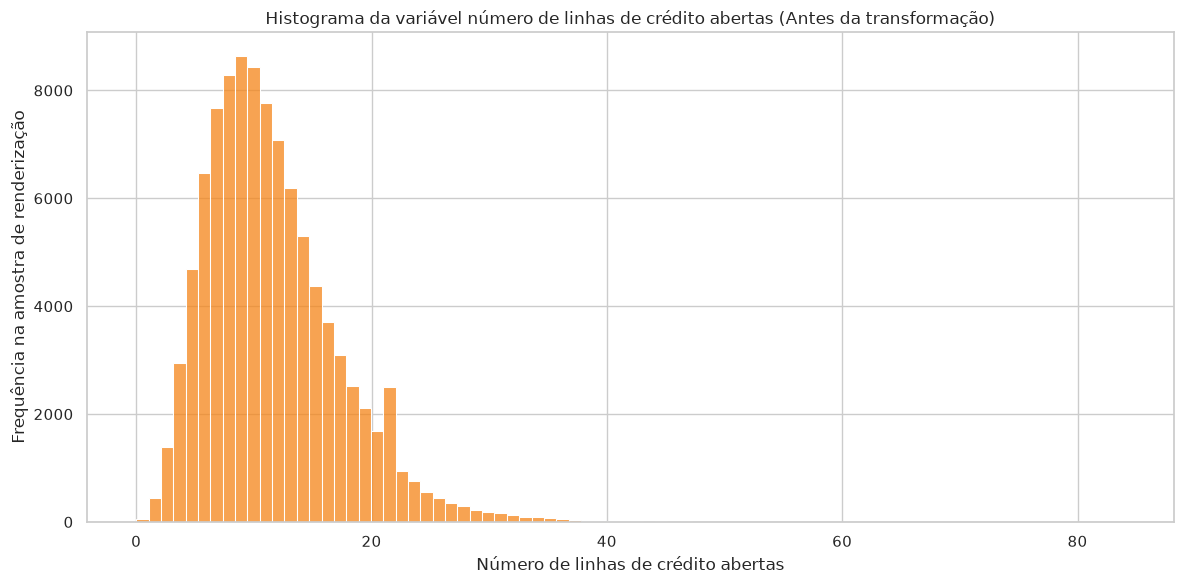

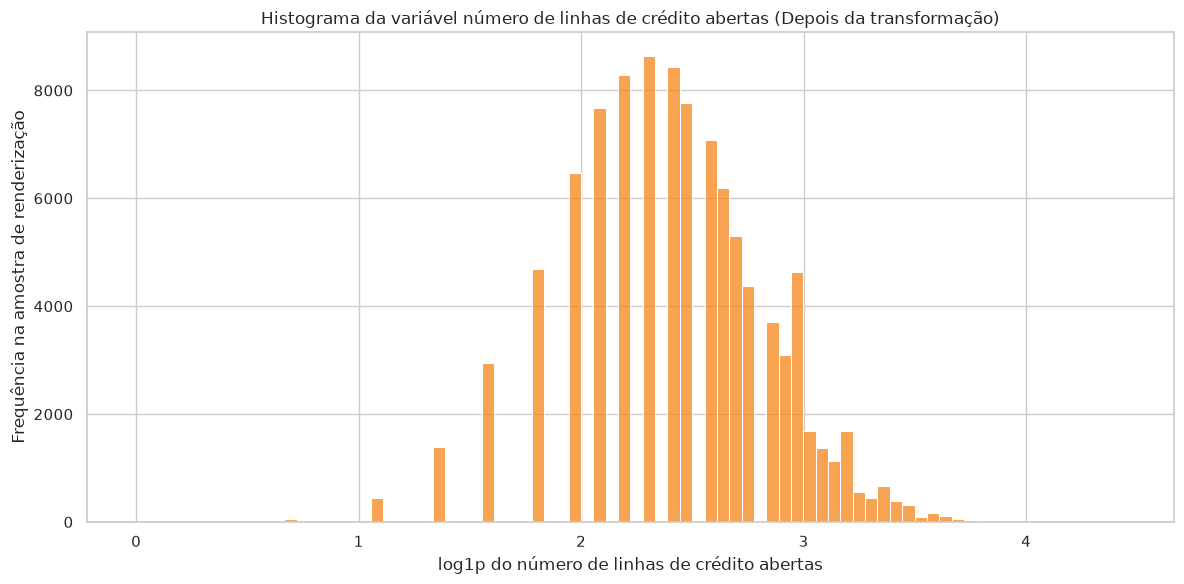

In [12]:
for figure_number, column, xlabel in (
    (18, "open_acc", "Número de linhas de crédito abertas"),
    (19, "open_acc_log1p", "log1p do número de linhas de crédito abertas"),
):
    plt.figure(figsize=(12, 6))
    ax = sns.histplot(
        data=plot_sample_verified,
        x=column,
        bins=80,
        color="#f58518",
    )
    ax.set(
        title=FIGURE_TITLES[figure_number],
        xlabel=xlabel,
        ylabel="Frequência na amostra de renderização",
    )
    plt.tight_layout()
    plt.show()

## 7. Limpeza e pré-processamento

**Origem:** tese, seção 4.3 e Tabelas 3–6; notebook recuperado, células 22–54; pipeline reconstruído nas Fases 2 e 5.  
**Tipo:** adaptado com correções metodológicas.  
**Mudança:** status e renda são filtrados explicitamente; datas, percentuais e FICO têm regras auditáveis; imputação, escala e one-hot ficam dentro dos pipelines ajustados somente no treino. `monthly_load` é criado sem aprender estatísticas da população.  
**Limitação:** as tabelas publicadas com linhas individuais são substituídas por esquema e agregados para não expor dados potencialmente sensíveis.

### Tabelas 3–6 — dados antes/depois do processamento

**Origem:** tese, Tabelas 3–6.  
**Tipo:** adaptado por segurança.  
**Mudança:** a tese publica cinco linhas individuais. A reconstrução registra a posição e o tratamento das dez colunas originais e perfis agregados das dez colunas correspondentes após os filtros/conversões da Fase 2. Nenhum identificador ou registro individual é exibido. Codificação e imputação permanecem para a Fase 5.

In [13]:
raw_columns = list(inspect_schema(DATASET_PATH))
first_ten_columns = raw_columns[:10]
raw_schema_audit = pd.DataFrame(
    {
        "posição_original": range(1, 11),
        "coluna": first_ten_columns,
        "disponível_no_pipeline_fase_2": [column in all_loans.columns for column in first_ten_columns],
    }
)

table_3 = raw_schema_audit.iloc[:5].reset_index(drop=True)
table_4 = raw_schema_audit.iloc[5:10].reset_index(drop=True)
display(table_3)
display(table_4)

,posição_original,coluna,disponível_no_pipeline_fase_2
0,1,Unnamed: 0,False
1,2,id,True
2,3,loan_amnt,True
3,4,funded_amnt,True
4,5,funded_amnt_inv,False


,posição_original,coluna,disponível_no_pipeline_fase_2
0,6,term,True
1,7,int_rate,True
2,8,installment,True
3,9,grade,True
4,10,sub_grade,True


In [14]:
processed_columns = [
    "loan_amnt",
    "funded_amnt",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "open_acc",
    "total_acc",
    "fico_range_low",
    "fico_range_high",
]
processed_profile = aggregate_column_profile(verified_loans, processed_columns)
table_5 = processed_profile.iloc[:5].reset_index(drop=True)
table_6 = processed_profile.iloc[5:10].reset_index(drop=True)
display(table_5)
display(table_6)

,coluna,tipo,não_nulos,ausentes,mínimo,mediana,máximo
0,loan_amnt,float64,1272273,0,1000.00,14000.00,4.000000e+04
1,funded_amnt,float64,1272273,0,1000.00,14000.00,4.000000e+04
2,int_rate,Float64,1272273,0,5.31,13.35,3.099000e+01
3,installment,float64,1272273,0,4.93,402.83,1.719830e+03
4,annual_inc,float64,1272273,0,0.00,65000.00,1.100000e+08


,coluna,tipo,não_nulos,ausentes,mínimo,mediana,máximo
0,dti,float64,1272149,124,-1.0,18.0,999.0
1,open_acc,float64,1272273,0,0.0,11.0,90.0
2,total_acc,float64,1272273,0,2.0,23.0,176.0
3,fico_range_low,float64,1272273,0,660.0,685.0,845.0
4,fico_range_high,float64,1272273,0,664.0,689.0,850.0


### Resultados observados e limites da análise exploratória

Os valores abaixo são calculados na execução atual com o dataset real. Eles sustentam a atualização de `docs/result-comparison.md` sem fabricar equivalência com as figuras publicadas.

Limites: os gráficos densos usam uma amostra determinística de 100.000 somente para renderização; correlações, contagens e perfis tabulares usam a população completa. A transformação `log1p` é exploratória e não constitui ajuste de um pipeline de modelo.

In [15]:
observed_results = correlations.copy()
observed_results["correlacao_tese"] = [1.00, 1.00, 0.71]
observed_results["diferença"] = (
    observed_results["correlacao_pearson"] - observed_results["correlacao_tese"]
)
observed_results

,variavel_x,variavel_y,n_pares_validos,correlacao_pearson,correlacao_tese,diferença
0,loan_amnt,funded_amnt,1860764,0.999700,1.00,-2.998806e-04
1,fico_range_low,fico_range_high,1860764,1.000000,1.00,-7.658783e-08
2,total_acc,open_acc,1860764,0.708775,0.71,-1.224766e-03


## 8. PoC 1 — recomendação baseada em conteúdo

**Origem:** tese, seção 4.4, Figuras 20–22 e Tabela 7. Esta PoC está ausente do notebook recuperado.  
**Tipo:** código novo de reconstrução, com uma versão forense fiel aos números publicados e uma adaptação normalizada.  
**Atributos:** `annual_inc`, `all_util`, `acc_open_past_24mths` e `grade`.  
**População:** amostra determinística de 10.000 empréstimos após os filtros de status e renda verificada da Fase 2, semente 42.  
**Limiar:** distância ≤ 20; a igualdade qualifica. Valores ausentes nunca qualificam.

A nota é codificada ordinalmente como A=1, B=2, ..., G=7. As fronteiras de elegibilidade são inclusivas. A distância bruta usa as escalas originais e, portanto, é dominada pela renda anual.

### Campanhas e divergência da fonte

- **Campanha 1:** renda ≥ 30.000; utilização ≤ 60%; ao menos 1 conta aberta em 24 meses; grade B–E.
- **Campanha 2:** renda ≥ 60.000; utilização ≤ 35%; ao menos 5 contas abertas em 24 meses; grade A–C.

A elegibilidade sempre conserva o máximo de 35% da Campanha 2. Entretanto, as quatro distâncias da Tabela 7 só são reproduzidas quando a referência de utilização dentro da distância da Campanha 2 é 40. A reconstrução mantém essa referência apenas no cálculo forense e também calcula a alternativa estrita com referência 35.

In [16]:
from tcc_reconstruction.poc1 import (
    CAMPAIGN_1,
    CAMPAIGN_2,
    CAMPAIGN_2_STRICT,
    DEFAULT_DISTANCE_THRESHOLD,
    evaluate_campaign,
    reproduce_table_7,
    robust_component_scales,
)

campaign_rules = pd.DataFrame(
    [
        {
            "campanha": CAMPAIGN_1.name,
            "renda_mínima": CAMPAIGN_1.minimum_annual_income,
            "utilização_máxima": CAMPAIGN_1.maximum_utilization,
            "contas_mínimas_24m": CAMPAIGN_1.minimum_recent_accounts,
            "grades": "B–E",
            "referência_utilização_distância": CAMPAIGN_1.distance_utilization_reference,
        },
        {
            "campanha": CAMPAIGN_2.name,
            "renda_mínima": CAMPAIGN_2.minimum_annual_income,
            "utilização_máxima": CAMPAIGN_2.maximum_utilization,
            "contas_mínimas_24m": CAMPAIGN_2.minimum_recent_accounts,
            "grades": "A–C",
            "referência_utilização_distância": CAMPAIGN_2.distance_utilization_reference,
        },
    ]
)
campaign_rules

,campanha,renda_mínima,utilização_máxima,contas_mínimas_24m,grades,referência_utilização_distância
0,Campanha 1,30000.0,60.0,1.0,B–E,60.0
1,Campanha 2,60000.0,35.0,5.0,A–C,40.0


### Tabela 7 — Resultados da Prova de Conceito

Os perfis Vinicius e Elder são exemplos sintéticos publicados na tese. A tabela abaixo reproduz as distâncias sem atribuí-las a registros reais do dataset.

In [17]:
table_7 = reproduce_table_7()
strict_campaign_2_examples = evaluate_campaign(table_7, CAMPAIGN_2_STRICT)
table_7_comparison = table_7.copy()
table_7_comparison["campaign_2_distance_strict_35"] = strict_campaign_2_examples["distance"]
table_7_comparison

,user_id,annual_inc,all_util,acc_open_past_24mths,grade,campaign_1_distance,campaign_1_qualified,campaign_2_distance,campaign_2_qualified,campaign_2_distance_strict_35
0,Vinicius,30000.0,55.0,1.0,C,5.000000,True,30000.004017,False,30000.006933
1,Elder,60000.0,35.0,5.0,A,30000.010433,False,5.000000,True,0.000000


### Execução na amostra determinística real

**Tipo:** novo.  
**Regra principal:** um perfil só é aprovado quando satisfaz todos os critérios declarados **e** possui distância bruta ≤ 20. Para diagnosticar os números publicados, também é contabilizado o resultado histórico que aplica somente a distância ≤ 20.

In [18]:
poc1_pipeline = run_data_pipeline(
    DataPipelineConfig(
        dataset_path=DATASET_PATH,
        sample_size=10_000,
        random_seed=SEED,
        verified_only=True,
    )
)
poc1_data = poc1_pipeline.data
poc1_features = ["annual_inc", "all_util", "acc_open_past_24mths", "grade"]

poc1_population = pd.DataFrame(
    {
        "métrica": ["amostra", *[f"ausentes: {column}" for column in poc1_features]],
        "registros": [
            len(poc1_data),
            *[int(poc1_data[column].isna().sum()) for column in poc1_features],
        ],
    }
)
poc1_population

,métrica,registros
0,amostra,10000
1,ausentes: annual_inc,0
2,ausentes: all_util,4716
3,ausentes: acc_open_past_24mths,237
4,ausentes: grade,0


In [19]:
normalization_scales = robust_component_scales(poc1_data)

campaign_1_raw = evaluate_campaign(poc1_data, CAMPAIGN_1)
campaign_2_raw = evaluate_campaign(poc1_data, CAMPAIGN_2)
campaign_2_strict = evaluate_campaign(poc1_data, CAMPAIGN_2_STRICT)
campaign_1_normalized = evaluate_campaign(
    poc1_data, CAMPAIGN_1, scales=normalization_scales
)
campaign_2_normalized = evaluate_campaign(
    poc1_data, CAMPAIGN_2, scales=normalization_scales
)

campaign_summary = pd.DataFrame(
    {
        "campanha": ["Campanha 1", "Campanha 2"],
        "elegíveis_pelos_critérios": [
            int(campaign_1_raw["eligible"].sum()),
            int(campaign_2_raw["eligible"].sum()),
        ],
        "aprovados_critérios_e_distância_bruta": [
            int(campaign_1_raw["qualified"].sum()),
            int(campaign_2_raw["qualified"].sum()),
        ],
        "somente_distância_bruta": [
            int(campaign_1_raw["distance"].le(DEFAULT_DISTANCE_THRESHOLD).sum()),
            int(campaign_2_raw["distance"].le(DEFAULT_DISTANCE_THRESHOLD).sum()),
        ],
        "critérios_e_distância_normalizada_≤20": [
            int(campaign_1_normalized["qualified"].sum()),
            int(campaign_2_normalized["qualified"].sum()),
        ],
    }
)

strict_comparison = pd.DataFrame(
    {
        "versão_Campanha_2": ["referência forense 40", "referência estrita 35"],
        "aprovados_critérios_e_distância_bruta": [
            int(campaign_2_raw["qualified"].sum()),
            int(campaign_2_strict["qualified"].sum()),
        ],
        "somente_distância_bruta": [
            int(campaign_2_raw["distance"].le(DEFAULT_DISTANCE_THRESHOLD).sum()),
            int(campaign_2_strict["distance"].le(DEFAULT_DISTANCE_THRESHOLD).sum()),
        ],
    }
)
display(normalization_scales.rename("IQR usado na normalização").to_frame())
display(campaign_summary)
display(strict_comparison)

,IQR usado na normalização
annual_inc,49000.0
all_util,27.0
acc_open_past_24mths,4.0
grade,2.0


,campanha,elegíveis_pelos_critérios,aprovados_critérios_e_distância_bruta,somente_distância_bruta,critérios_e_distância_normalizada_≤20
0,Campanha 1,1790,36,64,1790
1,Campanha 2,178,10,88,178


,versão_Campanha_2,aprovados_critérios_e_distância_bruta,somente_distância_bruta
0,referência forense 40,10,88
1,referência estrita 35,11,72


### Figura 20 — Total de aprovados em cada campanha

**População e regra:** amostra determinística de 10.000; critérios inclusivos declarados na tese e distância bruta ≤ 20. Os totais históricos baseados somente na distância permanecem na tabela anterior, não são apresentados como aprovações conformes.

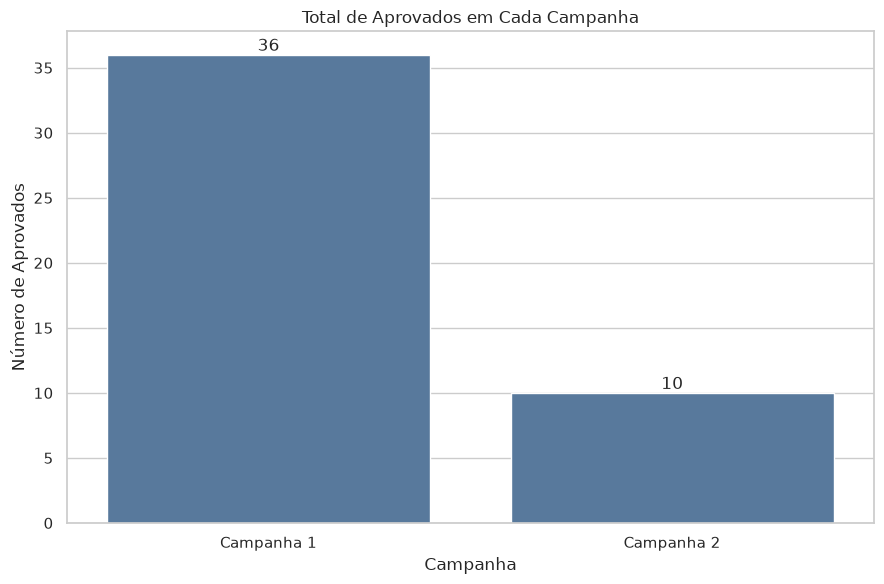

In [20]:
figure_20_data = campaign_summary[
    ["campanha", "aprovados_critérios_e_distância_bruta"]
].rename(columns={"aprovados_critérios_e_distância_bruta": "aprovados"})

plt.figure(figsize=(9, 6))
ax = sns.barplot(data=figure_20_data, x="campanha", y="aprovados", color="#4c78a8")
ax.set(
    title="Total de Aprovados em Cada Campanha",
    xlabel="Campanha",
    ylabel="Número de Aprovados",
)
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

### Figuras 21–22 — pontuação por distância

**Origem:** tese, Figuras 21–22.  
**Tipo:** reconstruído com API atual.  
**População:** os perfis da amostra com os quatro atributos presentes. A linha vermelha marca o limiar inclusivo 20. Os histogramas preservam a distância bruta e evidenciam o domínio da renda anual.

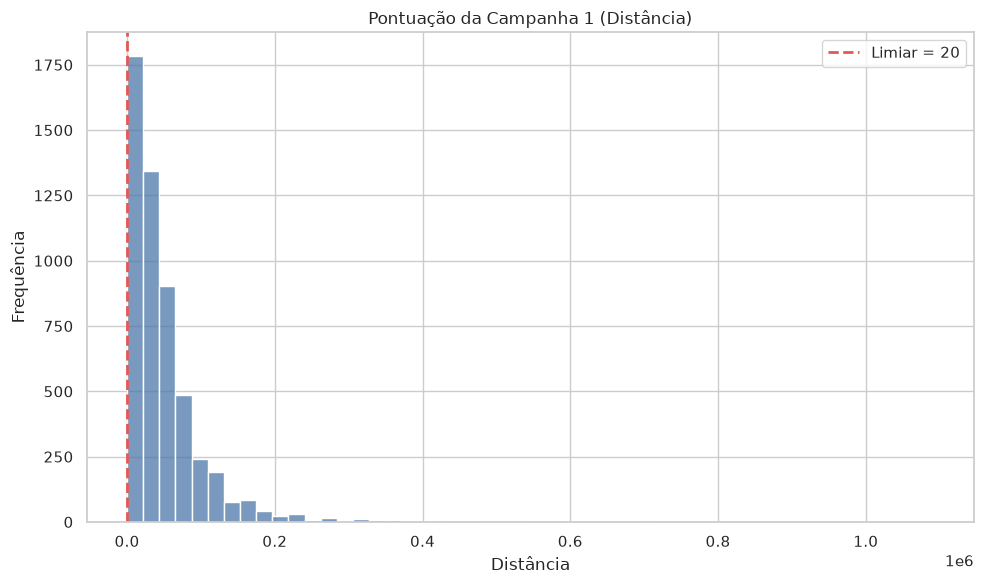

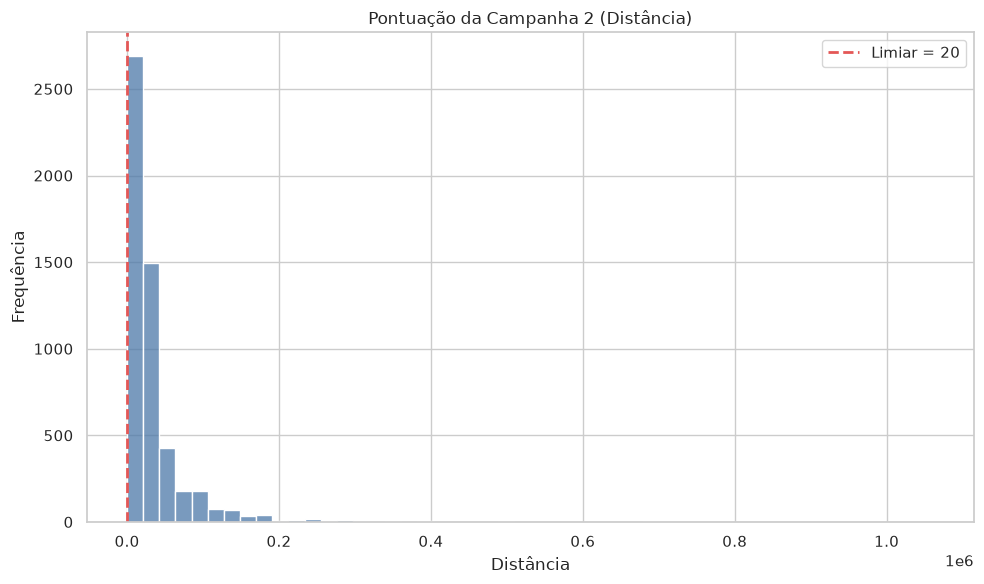

In [21]:
for figure_number, title, evaluation in (
    (21, "Pontuação da Campanha 1 (Distância)", campaign_1_raw),
    (22, "Pontuação da Campanha 2 (Distância)", campaign_2_raw),
):
    distances = evaluation["distance"].dropna()
    plt.figure(figsize=(10, 6))
    ax = sns.histplot(distances, bins=50, color="#4c78a8")
    ax.axvline(
        DEFAULT_DISTANCE_THRESHOLD,
        color="#e45756",
        linestyle="--",
        linewidth=2,
        label="Limiar = 20",
    )
    ax.set(title=title, xlabel="Distância", ylabel="Frequência")
    ax.legend()
    plt.tight_layout()
    plt.show()

### Sensibilidade — distância bruta versus normalizada

**Tipo:** adaptação nova. A normalização divide cada componente pelo intervalo interquartil observado na própria amostra. Isso evita o domínio numérico da renda, mas altera completamente a escala: reutilizar o limiar bruto 20 aprova todos os perfis elegíveis. Portanto, um limiar normalizado precisaria ser calibrado com objetivo de negócio ou validação externa; ele não é inventado nesta fase.

In [22]:
distance_comparison = pd.DataFrame(
    {
        "campanha": ["Campanha 1", "Campanha 2"],
        "mediana_distância_bruta": [
            campaign_1_raw["distance"].median(),
            campaign_2_raw["distance"].median(),
        ],
        "mediana_distância_normalizada": [
            campaign_1_normalized["distance"].median(),
            campaign_2_normalized["distance"].median(),
        ],
        "aprovados_bruta_≤20_com_critérios": [
            int(campaign_1_raw["qualified"].sum()),
            int(campaign_2_raw["qualified"].sum()),
        ],
        "aprovados_normalizada_≤20_com_critérios": [
            int(campaign_1_normalized["qualified"].sum()),
            int(campaign_2_normalized["qualified"].sum()),
        ],
    }
)
distance_comparison

,campanha,mediana_distância_bruta,mediana_distância_normalizada,aprovados_bruta_≤20_com_critérios,aprovados_normalizada_≤20_com_critérios
0,Campanha 1,35000.001157,1.108458,36,1790
1,Campanha 2,20400.025024,1.312271,10,178


### Resultado e limitações da PoC 1

Os resultados observados são mantidos nos outputs e comparados formalmente em `docs/result-comparison.md`. A proximidade de qualquer total publicado não é usada para alterar amostra, semente, fronteiras ou limiar. A ausência de `all_util` em parte da amostra reduz a população avaliável, e a discrepância entre elegibilidade e qualificação somente por distância impede alegar equivalência integral com a tese.

## 9. PoC 2 — baseline e XGBoost

**Origem:** tese, seção 4.5.1; notebook recuperado, células 22–76.  
**Tipo:** adaptado com correções metodológicas e baseline novo.  
**População:** todos os 1.272.273 empréstimos com status final e renda `Verified`/`Source Verified`.  
**Alvo:** `Fully Paid → 0`; `Charged Off` e `Default → 1`.  
**Separação:** 80% treino e 20% teste, estratificada, semente 1.  
**Sem vazamento:** `RandomUnderSampler`, imputadores, escalador e one-hot são ajustados somente dentro dos pipelines de treino. O teste preserva a distribuição natural.

A regressão logística é um baseline real e separado. O XGBoost usa `binary:logistic`; ROC e AUC usam probabilidades da classe inadimplente. AUC calculada com rótulos é mantida apenas como comparação histórica com o notebook recuperado.

### Reconciliação das variáveis

O Anexo A e a célula 37 enumeram 43 itens, mas um deles é o próprio alvo `default`. Assim, existem **42 preditores originais**, não 43. Com a variável derivada `monthly_load`, o modelo recebe **43 entradas**, e não 44 como afirma a narrativa da tese.

`monthly_load = ((installment × 12) / annual_inc) × 100`. Quando `annual_inc == 0`, o valor é `-1`, seguindo o notebook recuperado. `fico` permanece a média explícita dos limites criada na Fase 2. Categorias nominais usam one-hot, sem ordem artificial.

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

from tcc_reconstruction.poc2 import (
    CATEGORICAL_FEATURES,
    MODEL_FEATURES,
    PHASE5_RANDOM_SEED,
    PHASE5_TEST_SIZE,
    REDUCED_FEATURES,
    SOURCE_FEATURES,
    aggregate_xgboost_importance,
    build_logistic_pipeline,
    build_xgboost_pipeline,
    evaluate_classifier,
    prepare_supervised_data,
    resampled_class_counts,
)

X_phase5, y_phase5 = prepare_supervised_data(verified_loans)
X_train_phase5, X_test_phase5, y_train_phase5, y_test_phase5 = train_test_split(
    X_phase5,
    y_phase5,
    test_size=PHASE5_TEST_SIZE,
    random_state=PHASE5_RANDOM_SEED,
    stratify=y_phase5,
)

phase5_population = pd.DataFrame(
    {
        "partição": ["total", "treino antes do balanceamento", "teste"],
        "registros": [len(y_phase5), len(y_train_phase5), len(y_test_phase5)],
        "classe_0": [
            int(y_phase5.eq(0).sum()),
            int(y_train_phase5.eq(0).sum()),
            int(y_test_phase5.eq(0).sum()),
        ],
        "classe_1": [
            int(y_phase5.eq(1).sum()),
            int(y_train_phase5.eq(1).sum()),
            int(y_test_phase5.eq(1).sum()),
        ],
    }
)
phase5_population

,partição,registros,classe_0,classe_1
0,total,1272273,998429,273844
1,treino antes do balanceamento,1017818,798743,219075
2,teste,254455,199686,54769


In [24]:
feature_inventory = pd.DataFrame(
    {
        "feature": MODEL_FEATURES,
        "origem": ["derivada" if name == "monthly_load" else "Anexo A" for name in MODEL_FEATURES],
        "tratamento": [
            "one-hot ajustado no treino"
            if name in CATEGORICAL_FEATURES
            else "mediana ajustada no treino"
            for name in MODEL_FEATURES
        ],
    }
)
feature_reconciliation = pd.DataFrame(
    {
        "item": [
            "itens enumerados no Anexo A",
            "alvo dentro da enumeração",
            "preditores originais utilizáveis",
            "monthly_load derivada",
            "entradas efetivas do modelo",
        ],
        "quantidade": [43, 1, len(SOURCE_FEATURES), 1, len(MODEL_FEATURES)],
    }
)
display(feature_reconciliation)
display(feature_inventory)

,item,quantidade
0,itens enumerados no Anexo A,43
1,alvo dentro da enumeração,1
2,preditores originais utilizáveis,42
3,monthly_load derivada,1
4,entradas efetivas do modelo,43


,feature,origem,tratamento
0,year,Anexo A,mediana ajustada no treino
1,avg_cur_bal,Anexo A,mediana ajustada no treino
2,fico,Anexo A,mediana ajustada no treino
3,loan_amnt,Anexo A,mediana ajustada no treino
4,term,Anexo A,one-hot ajustado no treino
5,int_rate,Anexo A,mediana ajustada no treino
6,installment,Anexo A,mediana ajustada no treino
7,sub_grade,Anexo A,one-hot ajustado no treino
8,emp_length,Anexo A,mediana ajustada no treino
9,home_ownership,Anexo A,one-hot ajustado no treino


### Modelos com todas as variáveis

**Regressão logística:** baseline interpretável novo, com escala numérica.  
**XGBoost:** reconstrução adaptada do código recuperado, com objetivo correto de classificação binária e importância por ganho.  
**Balanceamento:** somente o treino é subamostrado; o teste não é balanceado nem usado no ajuste dos transformadores.

In [25]:
logistic_baseline_pipeline = build_logistic_pipeline(MODEL_FEATURES)
xgboost_full_pipeline = build_xgboost_pipeline(MODEL_FEATURES)

logistic_baseline_pipeline.fit(X_train_phase5, y_train_phase5)
xgboost_full_pipeline.fit(X_train_phase5, y_train_phase5)

logistic_test_metrics = evaluate_classifier(
    logistic_baseline_pipeline, X_test_phase5, y_test_phase5
)
xgboost_full_test_metrics = evaluate_classifier(
    xgboost_full_pipeline, X_test_phase5, y_test_phase5
)

training_balance = pd.DataFrame(
    [
        {"modelo": "Regressão logística", **resampled_class_counts(logistic_baseline_pipeline, y_train_phase5)},
        {"modelo": "XGBoost completo", **resampled_class_counts(xgboost_full_pipeline, y_train_phase5)},
    ]
).rename(columns={0: "classe_0", 1: "classe_1"})
training_balance

,modelo,classe_0,classe_1
0,Regressão logística,219075,219075
1,XGBoost completo,219075,219075


### Figura 23 — Importância das Variáveis no Modelo XGBoost

**Tipo de importância:** ganho (`gain`), agregado das colunas one-hot para o atributo de origem. Isso não é diretamente equivalente ao “F score” sem definição publicado pela tese.

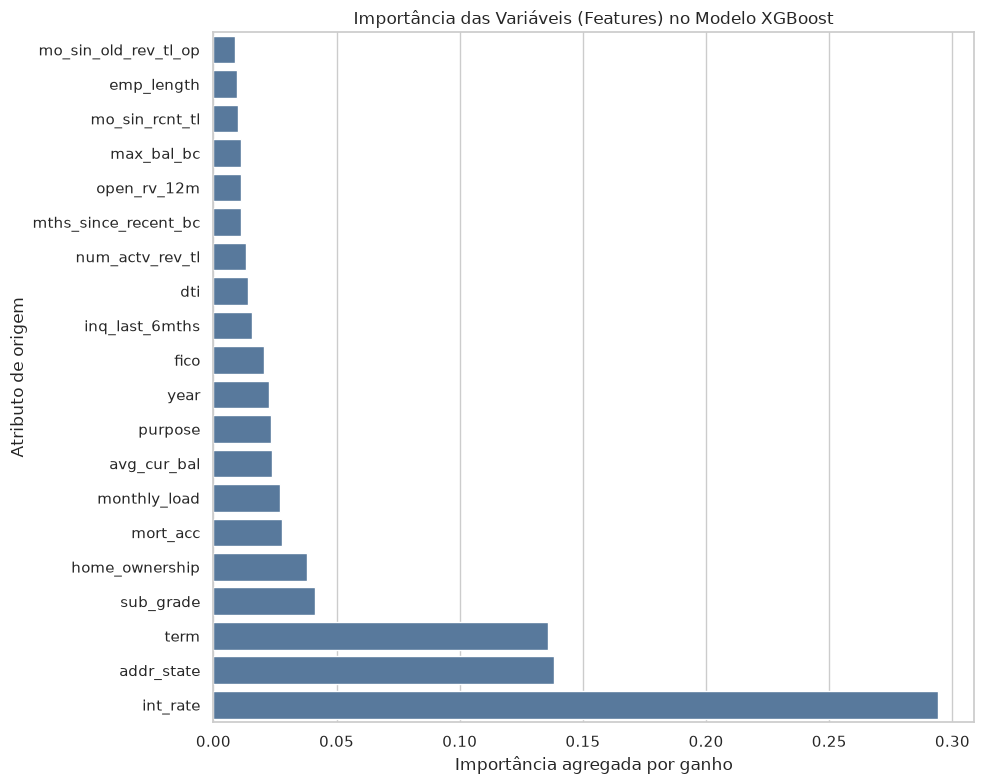

,feature,gain
0,int_rate,0.294044
1,addr_state,0.138330
2,term,0.136008
3,sub_grade,0.041180
4,home_ownership,0.038181
5,mort_acc,0.027806
6,monthly_load,0.027179
7,avg_cur_bal,0.023801
8,purpose,0.023266
9,year,0.022651


In [26]:
xgboost_full_importance = aggregate_xgboost_importance(
    xgboost_full_pipeline, MODEL_FEATURES
)
figure_23_data = xgboost_full_importance.head(20).sort_values("gain")

plt.figure(figsize=(10, 8))
ax = sns.barplot(data=figure_23_data, x="gain", y="feature", color="#4c78a8")
ax.set(
    title="Importância das Variáveis (Features) no Modelo XGBoost",
    xlabel="Importância agregada por ganho",
    ylabel="Atributo de origem",
)
plt.tight_layout()
plt.show()
xgboost_full_importance.head(20)

### Redução rastreável de atributos

A célula 63 recuperada conserva 12 atributos. A antiga dummy `TERM 60 months` é representada semanticamente pela coluna fonte `term`; `home_ownership` também permanece nominal e recebe one-hot. A lista foi fixada pela evidência histórica antes desta execução, sem consultar o conjunto de teste.

In [27]:
reduced_feature_trace = pd.DataFrame(
    {
        "feature_reduzida": REDUCED_FEATURES,
        "evidência": [
            "célula 63 recuperada; dummy histórica reconciliada com a fonte"
            if feature == "term"
            else "célula 63 recuperada"
            for feature in REDUCED_FEATURES
        ],
    }
)

xgboost_reduced_pipeline = build_xgboost_pipeline(REDUCED_FEATURES)
xgboost_reduced_pipeline.fit(
    X_train_phase5[list(REDUCED_FEATURES)], y_train_phase5
)
xgboost_reduced_test_metrics = evaluate_classifier(
    xgboost_reduced_pipeline,
    X_test_phase5[list(REDUCED_FEATURES)],
    y_test_phase5,
)
display(reduced_feature_trace)

,feature_reduzida,evidência
0,year,célula 63 recuperada
1,monthly_load,célula 63 recuperada
2,int_rate,célula 63 recuperada
3,avg_cur_bal,célula 63 recuperada
4,term,célula 63 recuperada; dummy histórica reconcil...
5,fico,célula 63 recuperada
6,dti,célula 63 recuperada
7,mo_sin_old_rev_tl_op,célula 63 recuperada
8,annual_inc,célula 63 recuperada
9,emp_length,célula 63 recuperada


In [28]:
def metric_row(name, metrics, feature_count):
    return {
        "modelo": name,
        "atributos_fonte": feature_count,
        "ROC_AUC_probabilidade": metrics["roc_auc_probability"],
        "ROC_AUC_rótulos_histórico": metrics["historical_roc_auc_labels"],
        "acurácia": metrics["accuracy"],
        "precisão_classe_0": metrics["class_0"]["precision"],
        "recall_classe_0": metrics["class_0"]["recall"],
        "F1_classe_0": metrics["class_0"]["f1-score"],
        "precisão_classe_1": metrics["class_1"]["precision"],
        "recall_classe_1": metrics["class_1"]["recall"],
        "F1_classe_1": metrics["class_1"]["f1-score"],
    }


phase5_metrics = pd.DataFrame(
    [
        metric_row("Regressão logística — completa", logistic_test_metrics, len(MODEL_FEATURES)),
        metric_row("XGBoost — completo", xgboost_full_test_metrics, len(MODEL_FEATURES)),
        metric_row("XGBoost — reduzido", xgboost_reduced_test_metrics, len(REDUCED_FEATURES)),
    ]
)
phase5_metrics

,modelo,atributos_fonte,ROC_AUC_probabilidade,ROC_AUC_rótulos_histórico,acurácia,...,recall_classe_0,F1_classe_0,precisão_classe_1,recall_classe_1,F1_classe_1
0,Regressão logística — completa,43,0.704407,0.647971,0.637154,...,0.628977,0.731233,0.330230,0.666965,0.441742
1,XGBoost — completo,43,0.711818,0.654009,0.647109,...,0.641893,0.740589,0.337831,0.666125,0.448301
2,XGBoost — reduzido,12,0.706897,0.649376,0.642593,...,0.637466,0.736799,0.333465,0.661286,0.443359


### Relatório do modelo XGBoost reduzido

O relatório abaixo usa o teste original e desbalanceado. “Precisão geral” da tese é interpretada como acurácia; precisão por classe, recall e F1 permanecem separados.

In [29]:
xgboost_reduced_report = pd.DataFrame(
    {
        "classe": ["0 — Fully Paid", "1 — Charged Off/Default"],
        "precision": [
            xgboost_reduced_test_metrics["class_0"]["precision"],
            xgboost_reduced_test_metrics["class_1"]["precision"],
        ],
        "recall": [
            xgboost_reduced_test_metrics["class_0"]["recall"],
            xgboost_reduced_test_metrics["class_1"]["recall"],
        ],
        "f1-score": [
            xgboost_reduced_test_metrics["class_0"]["f1-score"],
            xgboost_reduced_test_metrics["class_1"]["f1-score"],
        ],
        "support": [
            int(xgboost_reduced_test_metrics["class_0"]["support"]),
            int(xgboost_reduced_test_metrics["class_1"]["support"]),
        ],
    }
)
xgboost_reduced_report

,classe,precision,recall,f1-score,support
0,0 — Fully Paid,0.872802,0.637466,0.736799,199686
1,1 — Charged Off/Default,0.333465,0.661286,0.443359,54769


### Figura 24 — Matriz de Confusão

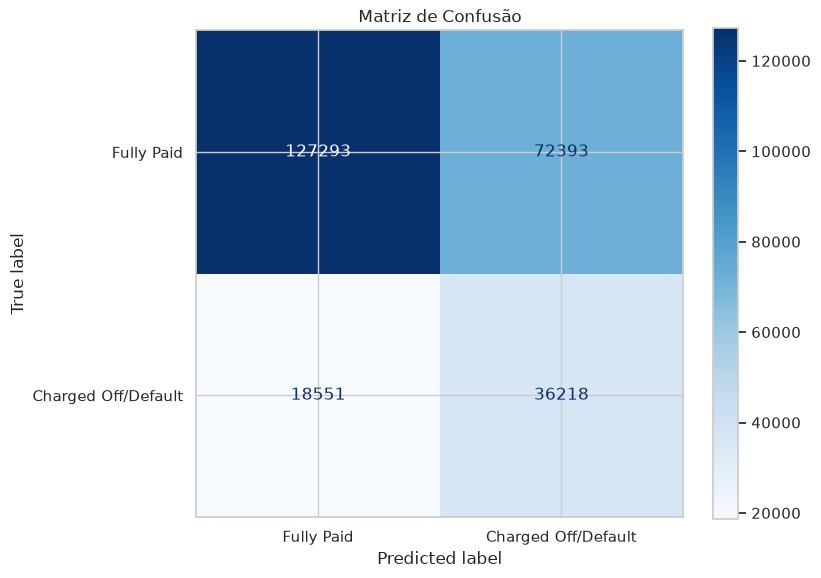

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix=np.asarray(xgboost_reduced_test_metrics["confusion_matrix"]),
    display_labels=["Fully Paid", "Charged Off/Default"],
).plot(cmap="Blues", values_format="d", ax=ax)
ax.set_title("Matriz de Confusão")
plt.tight_layout()
plt.show()

### Figura 25 — Curva ROC para o Modelo de Classificação

As duas curvas usam probabilidades. A curva de treino é uma medida de ajuste no treino original, antes de qualquer alegação de generalização; o teste permanece a avaliação principal.

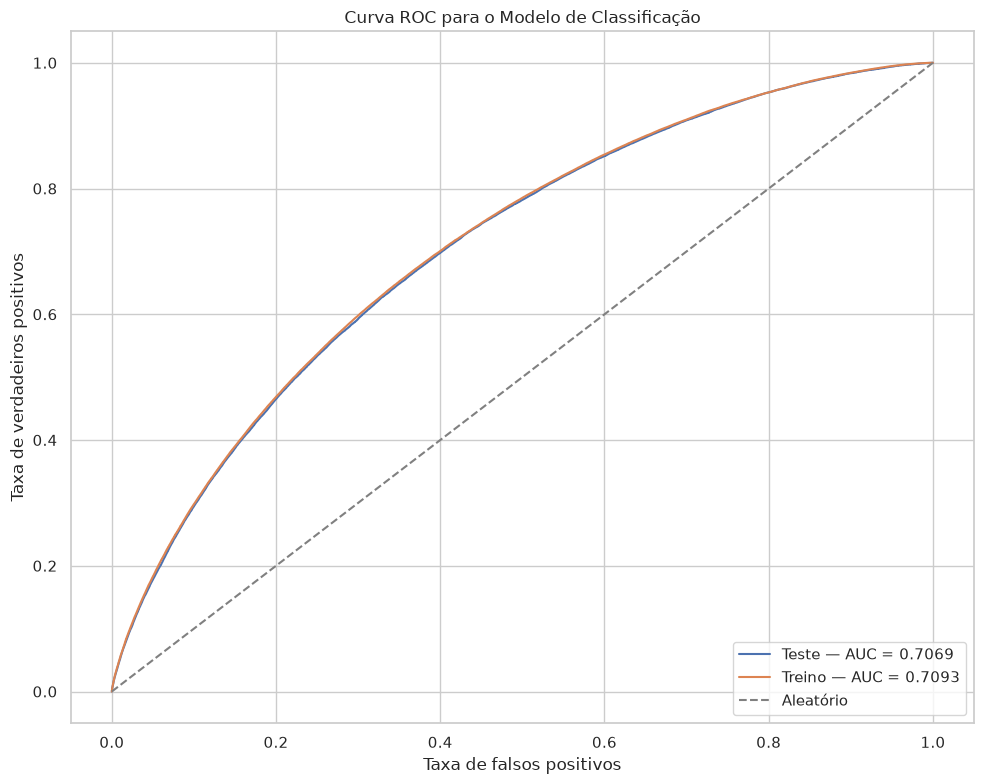

In [31]:
xgboost_reduced_train_probability = xgboost_reduced_pipeline.predict_proba(
    X_train_phase5[list(REDUCED_FEATURES)]
)[:, 1]
xgboost_reduced_test_probability = xgboost_reduced_test_metrics["probability"]

train_fpr, train_tpr, _ = roc_curve(y_train_phase5, xgboost_reduced_train_probability)
test_fpr, test_tpr, _ = roc_curve(y_test_phase5, xgboost_reduced_test_probability)
train_auc_probability = roc_auc_score(y_train_phase5, xgboost_reduced_train_probability)
test_auc_probability = xgboost_reduced_test_metrics["roc_auc_probability"]

plt.figure(figsize=(10, 8))
plt.plot(test_fpr, test_tpr, label=f"Teste — AUC = {test_auc_probability:.4f}")
plt.plot(train_fpr, train_tpr, label=f"Treino — AUC = {train_auc_probability:.4f}")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Aleatório")
plt.title("Curva ROC para o Modelo de Classificação")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Comparação histórica e limites

A tabela separa a avaliação correta por probabilidade do cálculo histórico por rótulos. `int_rate` e `sub_grade` são definidos pela plataforma e podem introduzir circularidade se o objetivo futuro for recomendar uma oferta antes da decisão; esta fase reproduz o conjunto publicado, mas registra o risco de disponibilidade temporal.

In [32]:
historical_comparison = pd.DataFrame(
    {
        "métrica": [
            "ROC AUC teste por probabilidade",
            "ROC AUC treino por probabilidade",
            "ROC AUC teste por rótulos — apenas histórico",
            "acurácia de teste",
            "precisão classe 0",
            "precisão classe 1",
        ],
        "tese": [0.65, 0.66, 0.65, 0.65, 0.88, 0.34],
        "reconstrução_XGBoost_reduzido": [
            test_auc_probability,
            train_auc_probability,
            xgboost_reduced_test_metrics["historical_roc_auc_labels"],
            xgboost_reduced_test_metrics["accuracy"],
            xgboost_reduced_test_metrics["class_0"]["precision"],
            xgboost_reduced_test_metrics["class_1"]["precision"],
        ],
    }
)
historical_comparison["diferença"] = (
    historical_comparison["reconstrução_XGBoost_reduzido"]
    - historical_comparison["tese"]
)
historical_comparison

,métrica,tese,reconstrução_XGBoost_reduzido,diferença
0,ROC AUC teste por probabilidade,0.65,0.706897,0.056897
1,ROC AUC treino por probabilidade,0.66,0.709264,0.049264
2,ROC AUC teste por rótulos — apenas histórico,0.65,0.649376,-0.000624
3,acurácia de teste,0.65,0.642593,-0.007407
4,precisão classe 0,0.88,0.872802,-0.007198
5,precisão classe 1,0.34,0.333465,-0.006535


### Resultado e limitações da PoC 2

Os modelos e probabilidades existem apenas na memória desta execução; nenhum binário é versionado. A calibração/transformação em score, categorias e ofertas pertence à Fase 6 e não é iniciada aqui. Os resultados observados são registrados em `docs/result-comparison.md` somente após esta execução reproduzível.

## 10. Score e taxa personalizada

**Origem:** tese, seções 4.5.2–4.5.3 e Figuras 26–29; notebook recuperado, células 77–91.  
**Tipo:** adaptado com correção de calibração e sentido explícito dos scores.

O notebook recuperado calcula `PD × 1000`: isso é um **score de risco**, no qual maior significa pior. A reconstrução preserva esse valor com o nome correto e cria seu inverso explícito, `score_credito = (1 − PD) × 1000`, no qual maior significa melhor. As categorias da tese `[G, F, E, D, C, B, A]` são aplicadas somente ao score de crédito; a inversão `[A, ..., G]` do notebook recuperado é mostrada apenas para conciliação forense.

### Calibração da probabilidade de inadimplência

**Código novo.** O treino da Fase 5 é novamente dividido, de forma estratificada, em ajuste (80%) e calibração (20%). Um novo XGBoost reduzido é ajustado somente na primeira parte; uma calibração sigmoide é ajustada somente na segunda. O teste permanece intocado. O Brier score mede calibração (menor é melhor) e ROC AUC mede discriminação.

In [33]:
from tcc_reconstruction.score import (
    ABOVE_SCORE_RANGE,
    BELOW_SCORE_RANGE,
    THESIS_CREDIT_CATEGORIES,
    categorize_credit_score,
    categorize_recovered_risk_score,
    category_b_interest_rate,
    evidenced_interest_offer,
    fit_sigmoid_calibrator,
    probability_metrics,
    probability_to_scores,
)

(
    X_model_train_phase6,
    X_calibration_phase6,
    y_model_train_phase6,
    y_calibration_phase6,
) = train_test_split(
    X_train_phase5,
    y_train_phase5,
    test_size=0.20,
    stratify=y_train_phase5,
    random_state=PHASE5_RANDOM_SEED,
)

xgboost_phase6_uncalibrated = build_xgboost_pipeline(REDUCED_FEATURES)
xgboost_phase6_uncalibrated.fit(
    X_model_train_phase6[list(REDUCED_FEATURES)], y_model_train_phase6
)
xgboost_phase6_calibrated = fit_sigmoid_calibrator(
    xgboost_phase6_uncalibrated,
    X_calibration_phase6[list(REDUCED_FEATURES)],
    y_calibration_phase6,
)

uncalibrated_test_pd = xgboost_phase6_uncalibrated.predict_proba(
    X_test_phase5[list(REDUCED_FEATURES)]
)[:, 1]
calibrated_test_pd = xgboost_phase6_calibrated.predict_proba(
    X_test_phase5[list(REDUCED_FEATURES)]
)[:, 1]
phase6_probability_comparison = pd.DataFrame(
    [
        {"probabilidade": "não calibrada", **probability_metrics(y_test_phase5, uncalibrated_test_pd)},
        {"probabilidade": "calibrada (sigmoide)", **probability_metrics(y_test_phase5, calibrated_test_pd)},
    ]
)
phase6_probability_comparison

,probabilidade,roc_auc,brier_score
0,não calibrada,0.706847,0.218330
1,calibrada (sigmoide),0.706847,0.153092


### Scores, categorias e linhas fora da faixa

Os limites publicados são 175, 225, 350, 475, 600, 725, 825 e 900. Como `pd.cut` no artefato usa intervalos fechados à direita, a reconstrução mantém essa convenção e inclui 175 no primeiro intervalo. Valores menores que 175 ou maiores que 900 recebem rótulos explícitos; não são descartados nem forçados para A–G.

In [34]:
phase6_scores = probability_to_scores(calibrated_test_pd)
phase6_scores["Categoria"] = categorize_credit_score(phase6_scores["credit_score"])
phase6_scores["Categoria_risco_recuperada"] = categorize_recovered_risk_score(
    phase6_scores["risk_score"]
)
phase6_category_order = [
    *reversed(THESIS_CREDIT_CATEGORIES),
    BELOW_SCORE_RANGE,
    ABOVE_SCORE_RANGE,
]
phase6_category_summary = (
    phase6_scores["Categoria"]
    .value_counts(dropna=False)
    .reindex(phase6_category_order, fill_value=0)
    .rename_axis("categoria_score_credito")
    .rename("registros")
    .reset_index()
)
phase6_category_summary

,categoria_score_credito,registros
0,A,66468
1,B,63158
2,C,45975
3,D,23277
4,E,4116
5,F,4
6,G,0
7,Fora da faixa: abaixo de 175,0
8,Fora da faixa: acima de 900,51457


### Oferta sustentada e exemplo de score 750

A tese afirma que a campanha atende D/E, mas só publica limites de taxa para o exemplo B: score 725–825 e taxa 13,33%–16,08%. Portanto, nenhuma taxa é fabricada para A ou C–G. A direção não é informada; adotamos a direção coerente com score de crédito: 725 recebe 16,08% e 825 recebe 13,33%. Assim, score 750 recebe **15,3925% a.a.** Os extremos e a monotonicidade são cobertos por testes.

In [35]:
score_750_category = categorize_credit_score([750]).iloc[0]
phase6_offer_example = pd.DataFrame(
    {
        "score_credito": [725.0, 750.0, 825.0],
        "categoria_publicada": ["B (limite)", score_750_category, "B (limite)"],
        "taxa_ofertada_pct_aa": [
            category_b_interest_rate(725),
            category_b_interest_rate(750),
            category_b_interest_rate(825),
        ],
    }
)
phase6_scores["taxa_ofertada_pct_aa"] = [
    evidenced_interest_offer(category, score)
    for category, score in zip(
        phase6_scores["Categoria"], phase6_scores["credit_score"], strict=True
    )
]
phase6_offer_example

,score_credito,categoria_publicada,taxa_ofertada_pct_aa
0,725.0,B (limite),16.0800
1,750.0,B,15.3925
2,825.0,B (limite),13.3300


### Figuras 26–29 — análise por categoria

**Código adaptado.** As Figuras 26–27 preservam os boxplots do artefato; outliers de DTI permanecem nos cálculos, mas são ocultados na renderização para legibilidade. As Figuras 28–29 substituem `dexplot`, não mantido, por proporções calculadas explicitamente. Somente categorias A–G aparecem nos gráficos; as linhas fora da faixa continuam contabilizadas na tabela anterior.

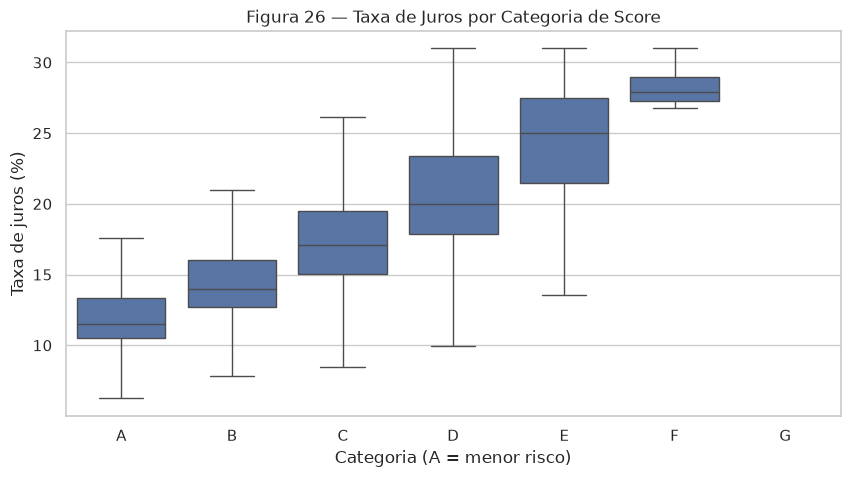

In [36]:
phase6_analysis = verified_loans.loc[
    X_test_phase5.index, ["int_rate", "dti", "home_ownership", "application_type"]
].reset_index(drop=True)
phase6_analysis = pd.concat([phase6_analysis, phase6_scores], axis=1)
phase6_in_range = phase6_analysis[
    phase6_analysis["Categoria"].isin(THESIS_CREDIT_CATEGORIES)
].copy()
phase6_in_range["Categoria"] = pd.Categorical(
    phase6_in_range["Categoria"], categories=list(reversed(THESIS_CREDIT_CATEGORIES)), ordered=True
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=phase6_in_range, x="Categoria", y="int_rate", order=list(reversed(THESIS_CREDIT_CATEGORIES)), showfliers=False, ax=ax)
ax.set(title="Figura 26 — Taxa de Juros por Categoria de Score", xlabel="Categoria (A = menor risco)", ylabel="Taxa de juros (%)")
plt.show()

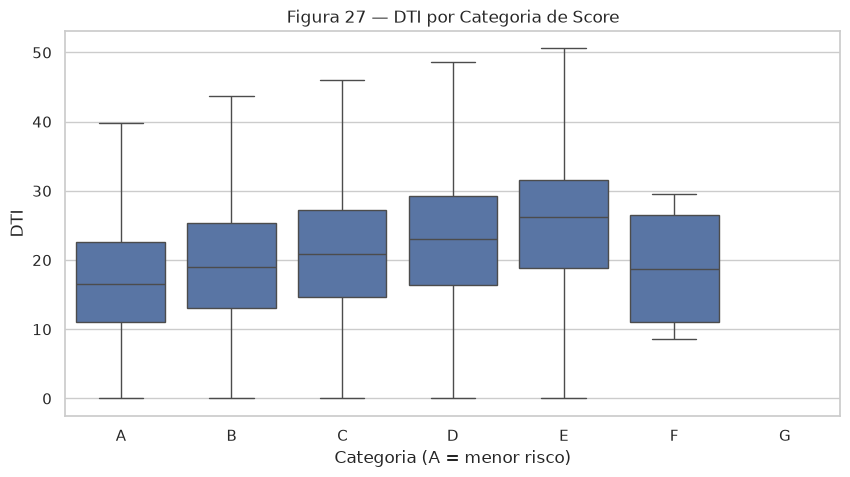

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=phase6_in_range, x="Categoria", y="dti", order=list(reversed(THESIS_CREDIT_CATEGORIES)), showfliers=False, ax=ax)
ax.set(title="Figura 27 — DTI por Categoria de Score", xlabel="Categoria (A = menor risco)", ylabel="DTI")
plt.show()

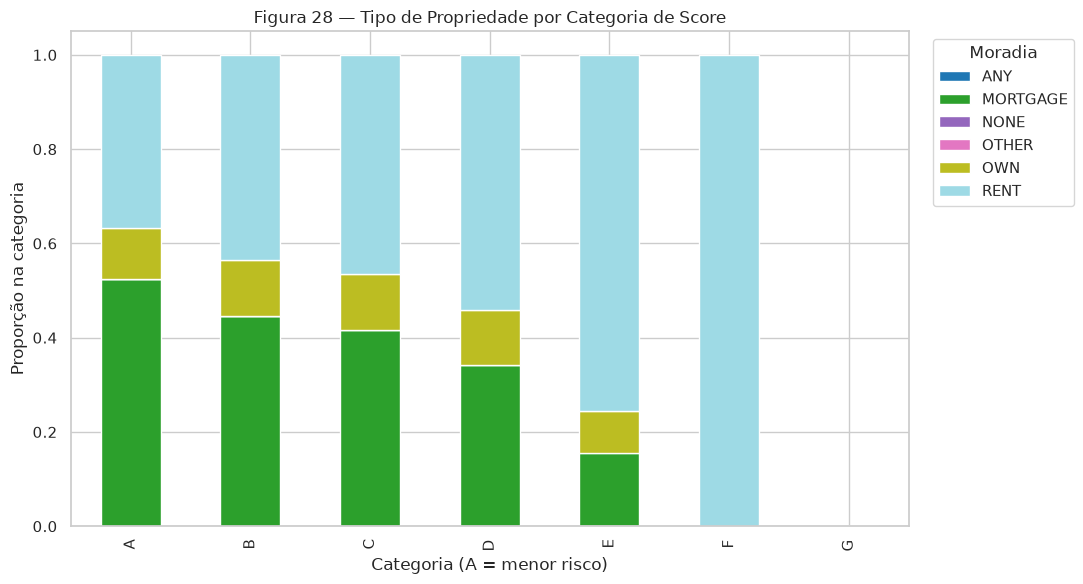

In [38]:
home_distribution = pd.crosstab(
    phase6_in_range["Categoria"], phase6_in_range["home_ownership"], normalize="index"
).reindex(list(reversed(THESIS_CREDIT_CATEGORIES)))
ax = home_distribution.plot(kind="bar", stacked=True, figsize=(11, 6), colormap="tab20")
ax.set(title="Figura 28 — Tipo de Propriedade por Categoria de Score", xlabel="Categoria (A = menor risco)", ylabel="Proporção na categoria")
ax.legend(title="Moradia", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

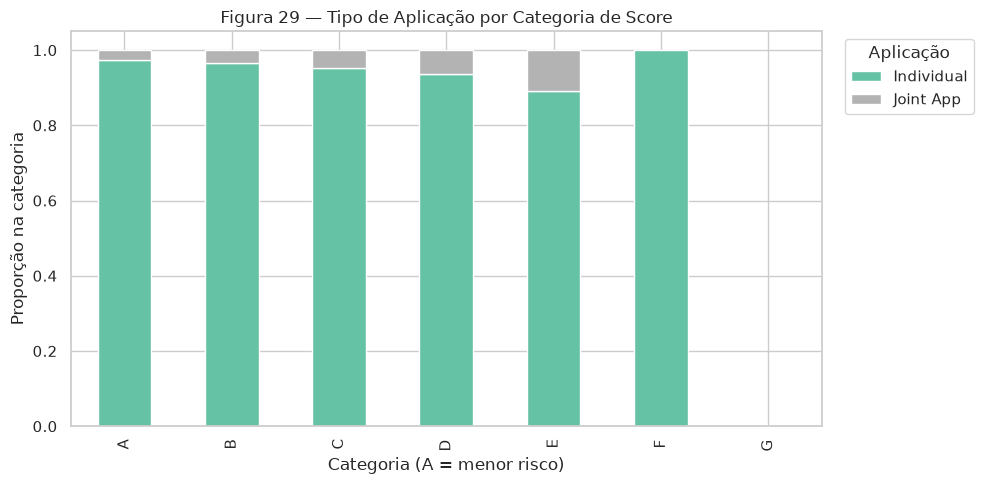

In [39]:
application_distribution = pd.crosstab(
    phase6_in_range["Categoria"], phase6_in_range["application_type"], normalize="index"
).reindex(list(reversed(THESIS_CREDIT_CATEGORIES)))
ax = application_distribution.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="Set2")
ax.set(title="Figura 29 — Tipo de Aplicação por Categoria de Score", xlabel="Categoria (A = menor risco)", ylabel="Proporção na categoria")
ax.legend(title="Aplicação", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Resultado e limitações do score e da oferta

As categorias são uma transformação do PD calibrado do modelo, não ratings externos validados. O score é uma escala linear interpretável, não uma equivalência alegada a bureaus de crédito. A oferta existe somente para B, única categoria com taxas publicadas. O conflito D/E versus B e a ambiguidade da direção da taxa permanecem registrados em `docs/result-comparison.md`.

## 11. Resultados

**Origem:** outputs executados nas Fases 3–6.  
**Tipo:** síntese nova, sem recalcular nem substituir os outputs anteriores.

- O arquivo contém 2.925.493 linhas; 1.860.764 permanecem após os status finais e 1.272.273 também possuem renda verificada.
- Na PoC 1, a regra completa reconstruiu 36 aprovações para a Campanha 1 e 10 para a Campanha 2; aplicar somente distância produz 64 e 88, expondo a ambiguidade histórica.
- No teste não balanceado da PoC 2, a regressão logística completa obteve AUC 0,704407, o XGBoost completo 0,711818 e o reduzido 0,706897.
- A calibração sigmoide do modelo reduzido preservou AUC 0,706847 e reduziu o Brier score de 0,218330 para 0,153092.
- O exemplo publicado de score 750 pertence à categoria B e resulta em 15,3925% a.a. sob a direção explícita de taxa decrescente com score de crédito.

Esses números pertencem à execução reconstruída. A classificação formal de cada comparação permanece no documento de resultados.

## 12. Comparação com a tese

**Origem:** resultados publicados, artefato recuperado e execução reconstruída.  
**Tipo:** síntese nova de `docs/result-comparison.md`.

As correlações arredondadas e a Tabela 7 foram reproduzidas. O AUC corporal próximo de 0,65 é explicado pelo cálculo histórico com rótulos; com probabilidades, os modelos alcançam aproximadamente 0,70–0,71. Totais da PoC 1, importância do XGBoost, curva de treino e categorias extremas apresentam divergências. O AUC 0,91 do apêndice e a campanha descrita para D/E sem limites de taxa correspondentes permanecem conflitantes. Nenhum resultado é promovido a ‘reproduzido’ apenas por proximidade visual.

## 13. Limitações

**Origem:** evidências forenses e resultados das Fases 1–6.  
**Tipo:** síntese crítica nova.

- A amostra histórica de 10.000 perfis da PoC 1 não possui seleção reproduzível documentada; a reconstrução usa semente 42.
- O notebook recuperado não preserva outputs finais e contém erros, vazamento e dependência de versões não registradas; a execução histórica exata não pode ser provada.
- O dataset disponível corresponde em dimensões e período à tese, mas igualdade do arquivo e da ordem de linhas usados historicamente não pode ser demonstrada.
- `int_rate` e `sub_grade` podem ser circulares numa decisão anterior à oferta; o momento de disponibilidade dos atributos exige definição de negócio.
- AUC mede discriminação, não benefício financeiro, justiça, estabilidade temporal ou adequação regulatória.
- Categorias e taxa são transformações internas do modelo, sem validação externa como rating ou score de bureau. Somente a categoria B possui limites de taxa publicados.
- As análises são descritivas e não sustentam causalidade; F possui quatro casos e G nenhum no teste calibrado.

## 14. Conclusões

**Origem:** objetivos da tese confrontados com a execução reconstruída.  
**Tipo:** conclusão nova e limitada pelas evidências.

Foi possível reconstruir as duas PoCs com o dataset real disponível, preservar a abordagem baseada em conteúdo, implementar baseline logístico e XGBoost separados e converter uma probabilidade calibrada em score de sentido explícito. A reconstrução também explica parte dos números históricos sem repetir AUC por rótulos, vazamento ou balanceamento do teste.

Os resultados demonstram uma implementação reproduzível desta metodologia, não equivalência integral à execução original nem prontidão para produção. Validação temporal, calibração externa das campanhas, governança dos atributos e avaliação de impacto permanecem trabalhos futuros.

## 15. Proveniência e notas de reconstrução

**Origem:** política de reconstrução do projeto.  
**Tipo:** novo.

- **Fonte primária:** `TCC_Vinicius_P_Souza.pdf`.
- **Artefato forense:** `notebooks/Copy of Trabalho Data Mining.ipynb`.
- **Cópia canônica byte a byte:** `notebooks/original-recovered.ipynb`.
- **Reconstrução:** este notebook, com código reutilizável em `src/tcc_reconstruction/`.
- **Recuperado:** lógica presente no artefato, mantida apenas quando compatível com a evidência e identificada na seção.
- **Adaptado:** lógica histórica com API atual, população explícita ou correção metodológica documentada.
- **Novo:** código, baseline, teste ou narrativa necessários e ausentes da fonte, sem atribuição ao autor da tese.

Hashes das fontes protegidas são verificados por `scripts/verify_source_integrity.py`. Divergências quantitativas e qualitativas ficam em `docs/result-comparison.md`; decisões forenses, em `docs/reconstruction-analysis.md`. Metadados de execução deste notebook pertencem à reconstrução e não são atribuídos ao autor da tese.